# Solving differential equations
## 1. Runge–Kutta Method

Runge–Kutta methods are higher-order numerical schemes derived from Taylor series expansions to improve accuracy over basic methods like Euler. In this notebook, we focus on their implementation and validate their performance through error and convergence analysis.


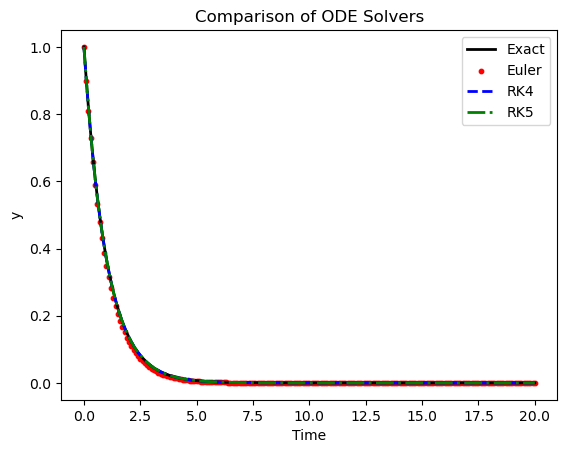

In [41]:
import sys
import os

sys.path.append("../src")
from euler import EulerODE
#sys.path.append(os.path.abspath(".."))  # go one level up to project root
#from src.euler import EulerODE
from rkmethods import rk4
from rkmethods import rk5

import numpy as np
import matplotlib.pyplot as plt
def f(t, y):
    return -y

t_1, y_1 = EulerODE(f, 0, 1, 200, 0.1)
t_2, y_2 = rk4(f, 0, 1, 200, 0.1)
t_3, y_3 = rk5(f, 0, 1, 200, 0.1)

t = t_1 # common time grid
y_exact = np.exp(-t)

plt.plot(t, y_exact, color='black', linewidth=2, label="Exact")

plt.scatter(t_1, y_1, color='red', s=10, label="Euler")

plt.plot(t_2, y_2, color='blue', linestyle='--', label="RK4")
plt.plot(t_3, y_3, color='green', linestyle='-.', label="RK5")
plt.xlabel("Time")
plt.ylabel("y")
plt.title("Comparison of ODE Solvers")
plt.legend()
plt.show()

We can see that all methods are accuarate for small h so its better to visualise their errors so as to analyse the differences better.

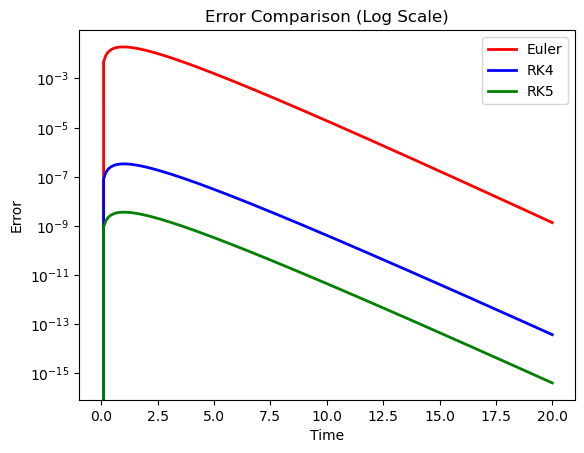

In [42]:
error_euler = np.abs(y_1 - y_exact)
error_rk4   = np.abs(y_2 - y_exact)
error_rk5   = np.abs(y_3 - y_exact)

plt.figure()

plt.plot(t, error_euler, color='red', label='Euler')
plt.plot(t, error_rk4, color='blue', label='RK4')
plt.plot(t, error_rk5, color='green', label='RK5')

plt.yscale('log')  # VERY IMPORTANT

plt.xlabel("Time")
plt.ylabel("Error")
plt.title("Error Comparison (Log Scale)")
plt.legend()
plt.show()

Now it is very easy for use to distinguish between all the three methods . The error is more in euler and a less in rk4 and lower in rk5 when compared to each other. We can now try convergence plot too

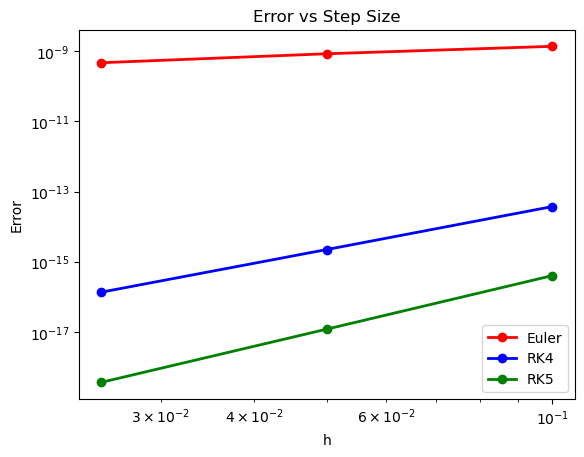

Euler order ≈ 0.78
RK4 order ≈ 4.05
RK5 order ≈ 5.04


In [43]:
hs = [ 0.1, 0.05, 0.025]
error_1 = []  #error for euler
error_2 = []  #error for rk4
error_3 = []  #error for rk5
T = 20

for h in hs:
     n = int(T/h) # consistant time
     t_1, y_1 = EulerODE(f, 0, 1, n, h)
     t_2, y_2 = rk4(f, 0, 1, n, h)
     t_3, y_3 = rk5(f, 0, 1, n, h)
     exact = np.exp(-20)
     error_1.append(np.abs(y_1[-1] - exact))
     error_2.append(np.abs(y_2[-1] - exact))
     error_3.append(np.abs(y_3[-1] - exact))

   
plt.loglog(hs, error_1, 'o-', color='red', label='Euler')
plt.loglog(hs, error_2, 'o-', color='blue', label='RK4')
plt.loglog(hs, error_3, 'o-', color='green', label='RK5')
plt.title("Error vs Step Size")
plt.xlabel("h")
plt.ylabel("Error")
plt.legend()
plt.show()
slope_1 = np.polyfit(np.log(hs), np.log(error_1), 1)[0] #Euler
slope_2 = np.polyfit(np.log(hs), np.log(error_2), 1)[0] #RK4
slope_3 = np.polyfit(np.log(hs), np.log(error_3), 1)[0] #RK5

# printing slope to find order 

print(f"Euler order ≈ {slope_1:.2f}")
print(f"RK4 order ≈ {slope_2:.2f}")
print(f"RK5 order ≈ {slope_3:.2f}")

The computed convergence slopes closely match the theoretical orders of accuracy: first-order for Euler, fourth-order for RK4, and fifth-order for RK5.


## Conclusion

The function for RK4 and RK5 closely aligns with the analytical values and  higher-order Runge–Kutta methods significantly reduce global error compared to Euler’s method. Convergence analysis confirms theoretical orders.